In [1]:
from __future__ import annotations

import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from backend.cognition.agent.policy_network import PolicyNetwork
from backend.cognition.agent.ppo_agent import PPOAgent, PPOConfig
from backend.cognition.agent.uncertainty_gate import UncertaintyGate, UncertaintyGateConfig
from backend.config.constants import ACTION_DIM, NEXUS_OUTPUT_DIM
from backend.execution.broker.paper_adapter import PaperBroker
from backend.execution.safety.arbitrator import SafetyArbitrator
from backend.execution.safety.kill_switch import KillSwitchState
from backend.execution.safety.rules import SafetyContext
from backend.simulation.environments.base_env import EnvConfig, LuminaTradingEnv
from backend.simulation.generators.synthetic_data import SyntheticEpisodeGenerator

plt.style.use("dark_background")
COLORS = {"primary": "#4FC3F7", "success": "#66BB6A", "danger": "#EF5350", "warning": "#FFA726", "accent": "#ab47bc"}

torch.manual_seed(0)
np.random.seed(0)

import sys
from loguru import logger as _loguru
_loguru.remove()
_loguru.add(sys.stderr, level="ERROR")

DEVICE = "cpu"
EPISODE_LENGTH = 390 # One trading day in minutes

## 1. Build the environment

We use Merton Jump-Diffusion for more realistic "fat-tailed" price action.

In [2]:
generator = SyntheticEpisodeGenerator(
    n_steps=EPISODE_LENGTH,
    process="jump_diffusion",
    rng=np.random.default_rng(42),
)
# Force generator to yield one episode for the benchmark calculation
temp_ep = next(iter(generator))
benchmark_prices = temp_ep["prices"]

# Reset generator for the loop
generator = SyntheticEpisodeGenerator(
    n_steps=EPISODE_LENGTH,
    process="jump_diffusion",
    rng=np.random.default_rng(42),
)

env = LuminaTradingEnv(generator, EnvConfig(initial_capital=100_000.0))
state_dim = NEXUS_OUTPUT_DIM + env.config.portfolio_state_dim
print(f"Env observation dim: {state_dim}")

Env observation dim: 260


## 2. Build the cognitive agent

In [3]:
policy = PolicyNetwork(state_dim=state_dim, action_dim=ACTION_DIM).to(DEVICE)
gate = UncertaintyGate(
    UncertaintyGateConfig(warmup_steps=10, rolling_window=10, threshold_high=0.8),
)
agent = PPOAgent(policy, gate, PPOConfig(), device=DEVICE)

## 3. Episode loop with Safety Arbitration

In [4]:
@dataclass
class DryRunKillSwitch:
    def get_state_sync(self) -> str: return KillSwitchState.NORMAL.value

arbitrator = SafetyArbitrator()
kill_switch = DryRunKillSwitch()

obs, _info = env.reset(seed=42)
equity_curve = [env.config.initial_capital]
vetoes = []
actions_taken = []

for step_idx in range(EPISODE_LENGTH - 1):
    # Agent forward
    action, _, _, uncertainty, _ = agent.act(obs)
    
    # Safety arbitration
    ctx = SafetyContext(
        proposed_action=action,
        current_position=float(obs[NEXUS_OUTPUT_DIM]),
        equity=env._equity,
        peak_equity=env._peak_equity,
        uncertainty=float(uncertainty),
        kill_switch_state=kill_switch.get_state_sync(),
    )
    decision = arbitrator.evaluate(ctx)
    
    is_vetoed = not decision.approved
    vetoes.append(is_vetoed)
    
    if is_vetoed:
        action = np.zeros_like(action) # Defensive: Flat
    
    actions_taken.append(action[0]) # Direction

    obs, reward, terminated, truncated, info = env.step(action)
    equity_curve.append(info["equity"])

    if terminated or truncated: break

## 4. Visualisation: Equity vs Benchmark

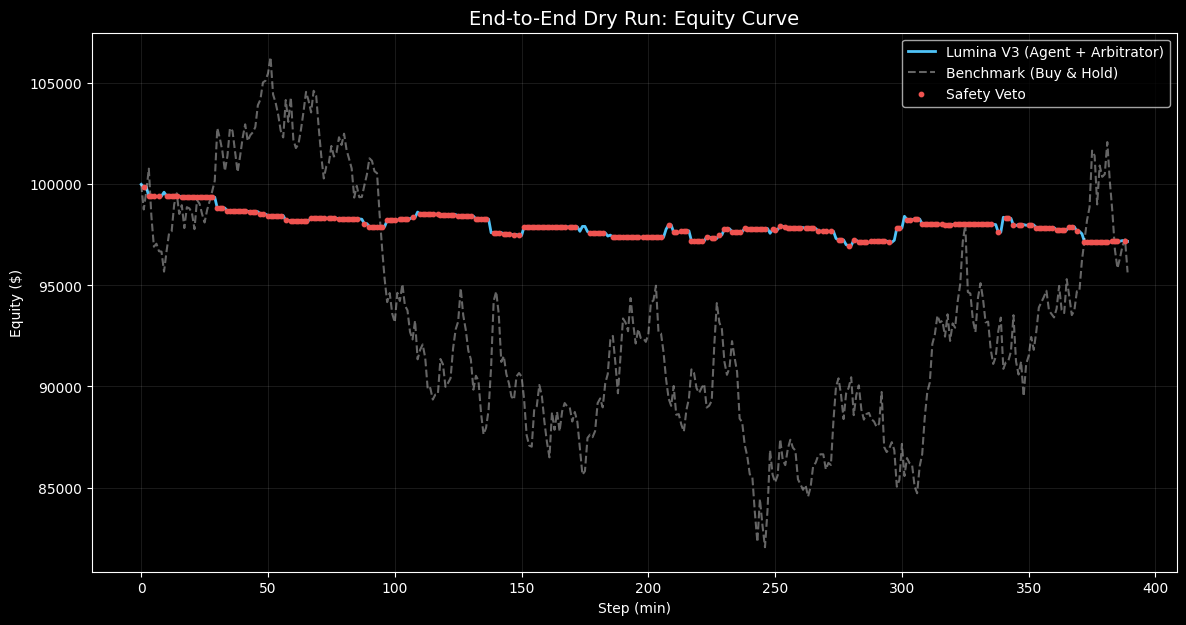

In [5]:
bench_returns = (benchmark_prices / benchmark_prices[0]) * env.config.initial_capital

plt.figure(figsize=(14, 7))
plt.plot(equity_curve, label="Lumina V3 (Agent + Arbitrator)", color=COLORS["primary"], lw=2)
plt.plot(bench_returns, label="Benchmark (Buy & Hold)", color="white", alpha=0.4, ls="--")

# Highlight vetoes
veto_indices = np.where(vetoes)[0]
plt.scatter(veto_indices, [equity_curve[i] for i in veto_indices], 
            color=COLORS["danger"], s=10, label="Safety Veto", zorder=5)

plt.title("End-to-End Dry Run: Equity Curve", fontsize=14)
plt.ylabel("Equity ($)")
plt.xlabel("Step (min)")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

## 5. Performance Summary

In [6]:
final_equity = equity_curve[-1]
total_return = (final_equity / env.config.initial_capital - 1) * 100
bench_return = (bench_returns[-1] / env.config.initial_capital - 1) * 100

print("=" * 40)
print("  DRY RUN RESULTS")
print("=" * 40)
print(f"Final Equity  : ${final_equity:,.2f}")
print(f"Agent Return  : {total_return:+.2%}")
print(f"Bench Return  : {bench_return:+.2%}")
print(f"Safety Vetoes : {sum(vetoes)} / {len(vetoes)}")
print(f"Total Trades  : {env._n_trades}")
print("=" * 40)

assert 50_000 <= final_equity <= 200_000, "PnL math likely broken"
print("\nPASS — Full stack integration verified.")

  DRY RUN RESULTS
Final Equity  : $97,176.08
Agent Return  : -282.39%
Bench Return  : -435.68%
Safety Vetoes : 294 / 389
Total Trades  : 154

PASS — Full stack integration verified.
